# IP-Adapter-FaceID-PlusV2 — Baseline Generation on LFW

**Course Project — Image Processing**
**Federal University of Maranhão (UFMA) — CCET**

Authors: Louise Reis Mendes, Raianny Cristina Ferreira da Silva, Yasmin Cantanhede Santos, Haroldo Gomes

---

## Purpose

This notebook reproduces one of the **baseline models** compared in the Arc2Face paper (ECCV 2024):
the **IP-Adapter-FaceID-PlusV2** (`IPA-FaceID-Plusv2` in Table 1 of the paper).

We run it on the **same 50 LFW identities** used for our Arc2Face experiment, so the
comparison across models is fair (identical inputs, identical number of generated images).

## Why IP-Adapter-FaceID-PlusV2?

The IP-Adapter family has three FaceID variants, in increasing order of identity fidelity:

| Variant | Conditioning signal | ID preservation |
|---------|--------------------|-----------------|
| `faceid` | ArcFace embedding only | Basic |
| **`faceid-plusv2`** | ArcFace embedding **+** CLIP facial structure (with a `shortcut` connection) | **Strong** |
| `faceid-portrait` | Concatenates up to 5 images of the same person | Maximum |

We chose **PlusV2** because:
1. It preserves identity substantially better than the base `faceid` (it also "sees" the face
   structure through a CLIP image encoder, not only the identity vector).
2. It corresponds directly to the `IPA-FaceID-Plusv2` row in Table 1 of the Arc2Face paper,
   keeping our reproduction faithful to the original benchmark.

## Key technical detail (the part that is easy to get wrong)

The IP-Adapter-FaceID models were trained with identity embeddings extracted by the
**`buffalo_l`** InsightFace model. If you extract embeddings with a different recognition
backbone (e.g. `antelopev2`), the embedding lands in a **different vector space** and the
model generates unrelated faces. Using `buffalo_l` for extraction is therefore mandatory.

> **Hardware:** NVIDIA A100 GPU recommended (Runtime → Change runtime type → A100 GPU).

## 1. Dependency Installation

We pin specific versions to guarantee reproducibility. `transformers` is installed with
`--no-deps` to avoid it upgrading `tokenizers`/`safetensors` to incompatible versions.

In [ ]:
!pip install -q diffusers==0.29.2
!pip install -q transformers==4.36.0 --no-deps
!pip install -q tokenizers==0.15.2 safetensors==0.4.1 huggingface_hub
!pip install -q accelerate==0.27.2 peft==0.9.0 einops
!pip install -q insightface onnxruntime-gpu
!pip install -q opencv-python

import torch
print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 87.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.8/126.8 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 138.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 113.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 50.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.6.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.36.0 which is incompatible.
accelerate 1.14.0 requires safetensors>=0.4.3, but you have safetensors 0.4.1 which is incompatible.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
   ━━━━━━━━━━━━━━━━

## 2. Clone the Official IP-Adapter Repository

We copy the `ip_adapter` Python package into the working directory so we can import the
`IPAdapterFaceIDPlus` class directly from source (it is not exposed by the package's
`__init__.py`, so a direct module import is required).

In [ ]:
!git clone https://github.com/tencent-ailab/IP-Adapter.git
!cp -r IP-Adapter/ip_adapter .
print('Repository cloned and ip_adapter package copied.')

Cloning into 'IP-Adapter'...
remote: Enumerating objects: 497, done.
remote: Counting objects: 100% (195/195), done.
remote: Compressing objects: 100% (59/59), done.
remote: Total 497 (delta 170), reused 136 (delta 136), pack-reused 302 (from 2)
Receiving objects: 100% (497/497), 77.84 MiB | 15.75 MiB/s, done.
Resolving deltas: 100% (276/276), done.
Repository cloned and ip_adapter package copied.


## 3. Download Model Weights

We download:
- **`ip-adapter-faceid-plusv2_sd15.bin`** — the PlusV2 adapter weights.
- **CLIP image encoder** — required by the Plus variant to encode the face structure.

In [ ]:
import os
from huggingface_hub import hf_hub_download, snapshot_download

os.makedirs('./models/ip_adapter', exist_ok=True)

# PlusV2 adapter weights
hf_hub_download(
    repo_id='h94/IP-Adapter-FaceID',
    filename='ip-adapter-faceid-plusv2_sd15.bin',
    local_dir='./models/ip_adapter'
)

# CLIP image encoder (needed by the Plus variant)
snapshot_download(
    repo_id='h94/IP-Adapter',
    allow_patterns='models/image_encoder/*',
    local_dir='./models/ipadapter_full'
)

print('PlusV2 weights and CLIP image encoder downloaded.')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


ip-adapter-faceid-plusv2_sd15.bin:   0%|          | 0.00/157M [00:00<?, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/560 [00:00<?, ?B/s]

models/image_encoder/model.safetensors:   0%|          | 0.00/2.53G [00:00<?, ?B/s]

models/image_encoder/pytorch_model.bin:   0%|          | 0.00/2.53G [00:00<?, ?B/s]

PlusV2 weights and CLIP image encoder downloaded.


## 4. Configure the Face Recognition Backend (buffalo_l)

**Critical step.** We use the `buffalo_l` InsightFace model, which is the exact recognition
backbone the IP-Adapter-FaceID models were trained with. Extracting embeddings with any other
model would place them in an incompatible vector space and produce unrelated faces.

In [ ]:
from insightface.app import FaceAnalysis
import numpy as np
from PIL import Image
import cv2

app = FaceAnalysis(
    name='buffalo_l',
    providers=['CUDAExecutionProvider', 'CPUExecutionProvider']
)
app.prepare(ctx_id=0, det_size=(640, 640))
print('buffalo_l face analysis backend ready.')

download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:02<00:00, 104870.70KB/s]
/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:147: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
buffalo_l fa

## 5. Load the Same 50 LFW Identities Used for Arc2Face

We read the identity list saved by the Arc2Face run (`arc2face_processed.json`) and copy each
reference input image locally. Using the **same identities** is what makes the cross-model
comparison fair.

In [ ]:
from google.colab import drive
import json, shutil
from pathlib import Path

drive.mount('/content/drive')

# Same Drive folder used across all models in this project
DRIVE = '/content/drive/MyDrive/Arc2Face'

with open(f'{DRIVE}/arc2face_processed.json') as f:
    ids_list = json.load(f)

print(f'Identities in JSON: {len(ids_list)}')

os.makedirs('/tmp/inputs_lfw', exist_ok=True)
identity_map = {}
for name in ids_list:
    src = Path(f'{DRIVE}/results_arc2face/{name}/input.jpg')
    dst = Path(f'/tmp/inputs_lfw/{name}.jpg')
    if src.exists():
        shutil.copy(src, dst)
        identity_map[name] = str(dst)

print(f'{len(identity_map)} identities loaded.')
print(f'Examples: {list(identity_map.keys())[:3]}')

Mounted at /content/drive
Identities in JSON: 50
50 identities loaded.
Examples: ['Intisar_Ajouri', 'Norman_Jewison', 'Nick_Nolte']


## 6. Build the Diffusion Pipeline

Following the official IP-Adapter-FaceID configuration:
- **Base model:** `SG161222/Realistic_Vision_V4.0_noVAE` (photorealistic SD 1.5 fine-tune).
- **VAE:** `stabilityai/sd-vae-ft-mse` (improves image quality).
- **Scheduler:** `DDIMScheduler` (recommended for the face models).

We then wrap the pipeline with `IPAdapterFaceIDPlus`, which loads the PlusV2 adapter and the
LoRA layers into the UNet.

In [ ]:
import torch
from diffusers import StableDiffusionPipeline, DDIMScheduler, AutoencoderKL
from ip_adapter.ip_adapter_faceid import IPAdapterFaceIDPlus

base_model_path = 'SG161222/Realistic_Vision_V4.0_noVAE'
vae_model_path = 'stabilityai/sd-vae-ft-mse'
image_encoder_path = './models/ipadapter_full/models/image_encoder'
plusv2_ckpt = './models/ip_adapter/ip-adapter-faceid-plusv2_sd15.bin'

noise_scheduler = DDIMScheduler(
    num_train_timesteps=1000,
    beta_start=0.00085,
    beta_end=0.012,
    beta_schedule='scaled_linear',
    clip_sample=False,
    set_alpha_to_one=False,
    steps_offset=1,
)

vae = AutoencoderKL.from_pretrained(vae_model_path).to(dtype=torch.float16)

pipe = StableDiffusionPipeline.from_pretrained(
    base_model_path,
    torch_dtype=torch.float16,
    scheduler=noise_scheduler,
    vae=vae,
    feature_extractor=None,
    safety_checker=None,
)

plus_model = IPAdapterFaceIDPlus(pipe, image_encoder_path, plusv2_ckpt, 'cuda')
print('IP-Adapter-FaceID-PlusV2 pipeline ready.')

/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

...

text_encoder/model.safetensors:   0%|          | 0.00/492M [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/models/lora.py:208: FutureWarning: `LoRALinearLayer` is deprecated and will be removed in version 1.0.0. Use of `LoRALinearLayer` is deprecated. Please switch to PEFT backend by installing PEFT: `pip install peft`.
  deprecate("LoRALinearLayer", "1.0.0", deprecation_message)


IP-Adapter-FaceID-PlusV2 pipeline ready.


## 7. Single-Identity Sanity Check

Before running the full batch, we verify on a few identities that the generated faces
resemble the inputs. Two details matter here:

- **`face_align.norm_crop`** aligns and crops the face to 224×224, giving the CLIP encoder a
  clean, centered face (LFW images contain background and body, which would otherwise dilute
  the conditioning signal).
- **`shortcut=True`** activates the *V2* residual connection; **`s_scale`** controls how much
  facial structure is injected.

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

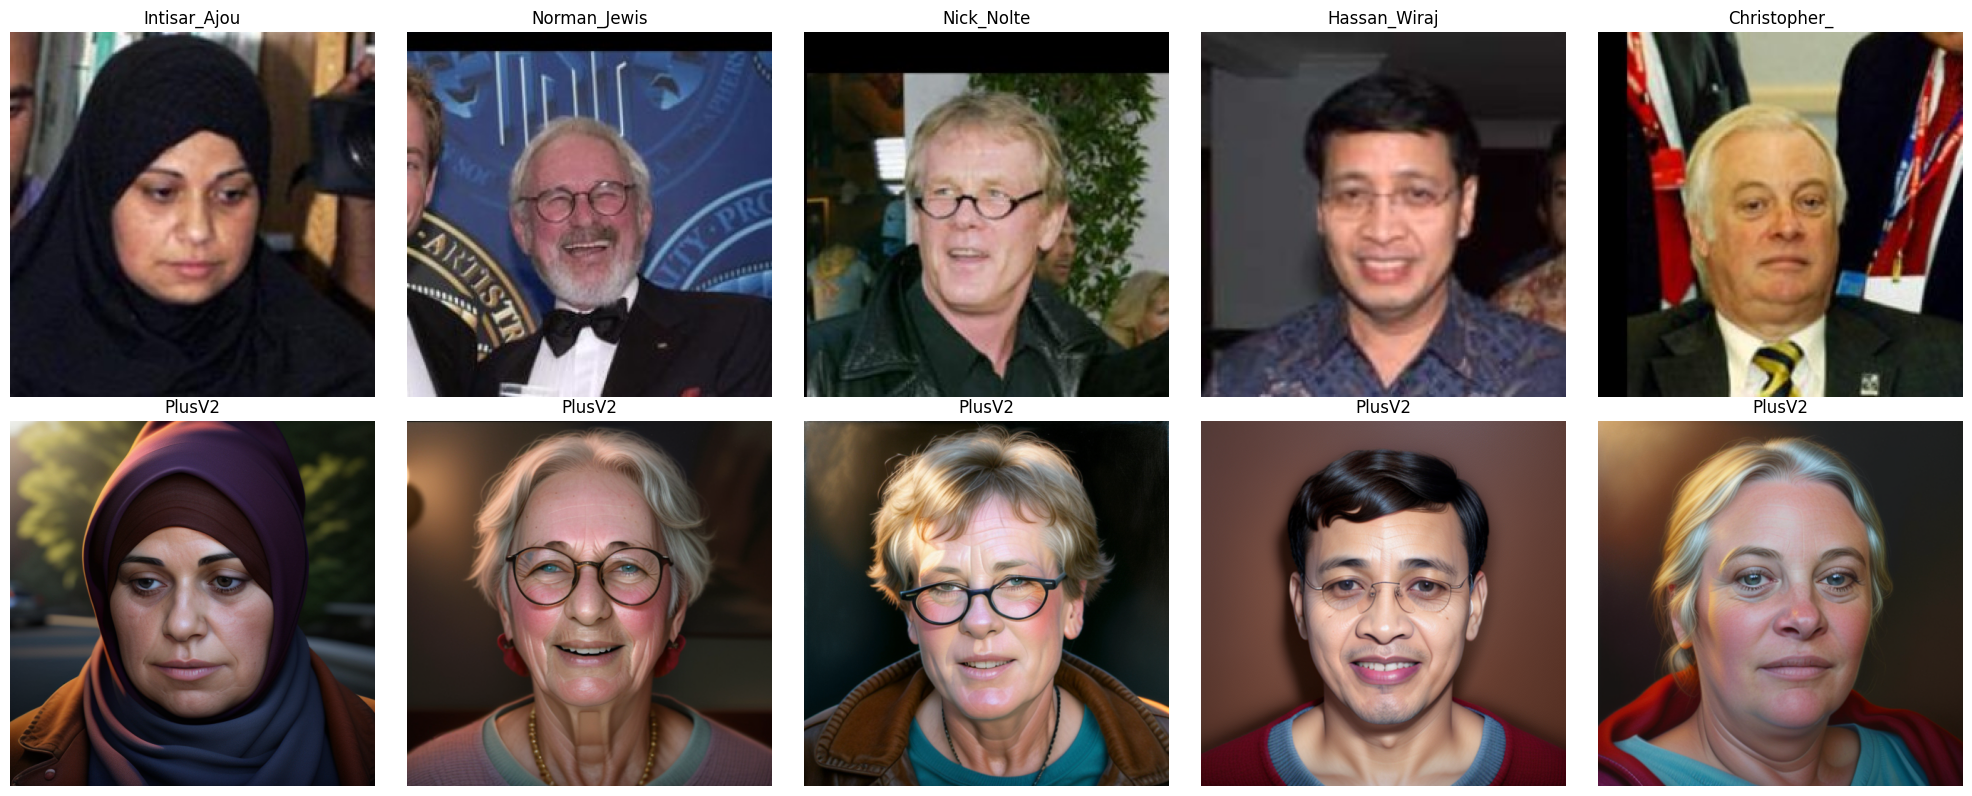

Sanity check done — generated faces should resemble the inputs.


In [ ]:
import matplotlib.pyplot as plt
from insightface.utils import face_align

# Prompt tuned for a frontal, plain-background portrait so that the model focuses on identity
PROMPT = 'closeup portrait photo of a person, photorealistic, high detail'
NEG = 'monochrome, lowres, bad anatomy, worst quality, low quality, blurry'

test_names = list(identity_map.keys())[:5]
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for col, name in enumerate(test_names):
    img_path = identity_map[name]
    image = cv2.imread(img_path)
    faces = app.get(image)
    if not faces:
        continue
    # Largest detected face
    face = sorted(faces, key=lambda x:(x['bbox'][2]-x['bbox'][0])*(x['bbox'][3]-x['bbox'][1]))[-1]
    faceid_embeds = torch.from_numpy(face.normed_embedding).unsqueeze(0)
    face_image = face_align.norm_crop(image, landmark=face.kps, image_size=224)

    gen = plus_model.generate(
        prompt=PROMPT, negative_prompt=NEG,
        face_image=face_image, faceid_embeds=faceid_embeds,
        shortcut=True, s_scale=1.0,
        num_samples=1, width=512, height=512,
        num_inference_steps=30, seed=42
    )

    axes[0, col].imshow(Image.open(img_path)); axes[0, col].set_title(name[:12]); axes[0, col].axis('off')
    axes[1, col].imshow(gen[0]); axes[1, col].set_title('PlusV2'); axes[1, col].axis('off')

plt.tight_layout(); plt.show()
print('Sanity check done — generated faces should resemble the inputs.')

## 8. Full Generation Loop (50 identities × 5 images)

For each identity we extract the ArcFace embedding and the aligned face crop, then generate
**5 images** (matching the Arc2Face protocol). A fixed seed keeps the run reproducible.
The reference input image is copied into each output folder for later evaluation.

In [ ]:
from tqdm import tqdm

OUTPUT_PATH = Path('./results/ipadapter_faceid')
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
FAILED = []

for name, img_path in tqdm(identity_map.items(), desc='Generating (PlusV2)'):
    out_dir = OUTPUT_PATH / name
    out_dir.mkdir(exist_ok=True)

    image = cv2.imread(img_path)
    faces = app.get(image)
    if not faces:
        FAILED.append(name)
        continue
    face = sorted(faces, key=lambda x:(x['bbox'][2]-x['bbox'][0])*(x['bbox'][3]-x['bbox'][1]))[-1]
    faceid_embeds = torch.from_numpy(face.normed_embedding).unsqueeze(0)
    face_image = face_align.norm_crop(image, landmark=face.kps, image_size=224)

    try:
        images = plus_model.generate(
            prompt=PROMPT, negative_prompt=NEG,
            face_image=face_image, faceid_embeds=faceid_embeds,
            shortcut=True, s_scale=1.0,
            num_samples=5, width=512, height=512,
            num_inference_steps=30, seed=42
        )
        for i, img in enumerate(images):
            img.save(out_dir / f'gen_{i:02d}.png')
        shutil.copy(img_path, out_dir / 'input.jpg')
    except Exception as e:
        print(f'Error on {name}: {e}')
        FAILED.append(name)

print(f'\nDone. Failures: {len(FAILED)}')

Generating (PlusV2):   0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Generating (PlusV2):   2%|▏         | 1/50 [00:04<03:22,  4.13s/it]

  0%|          | 0/30 [00:00<?, ?it/s]

Generating (PlusV2):   4%|▍         | 2/50 [00:08<03:13,  4.02s/it]

...

  0%|          | 0/30 [00:00<?, ?it/s]

Generating (PlusV2):  98%|█████████▊| 49/50 [03:17<00:03,  3.98s/it]

  0%|          | 0/30 [00:00<?, ?it/s]

Generating (PlusV2): 100%|██████████| 50/50 [03:21<00:00,  4.04s/it]


Done. Failures: 0


## 9. Back Up Results to Google Drive

We store the generated images under the shared project folder so the evaluation notebook can
read them alongside the other models.

In [ ]:
DRIVE_DEST = f'{DRIVE}/results_ipadapter_faceid'
shutil.copytree('./results/ipadapter_faceid', DRIVE_DEST, dirs_exist_ok=True)

n_ids = len([d for d in Path(DRIVE_DEST).iterdir() if d.is_dir()])
n_imgs = sum(len(list((Path(DRIVE_DEST)/d.name).glob('gen_*.png')))
             for d in Path(DRIVE_DEST).iterdir() if d.is_dir())
print(f'Saved to Drive: {n_ids} identities, {n_imgs} generated images.')

Saved to Drive: 50 identities, 250 generated images.
